# Part B Single-Image Explainer

This notebook explains the **ShanghaiTech Part B** pipeline on one sample image.

It covers:

1. loading one image  
2. obtaining actual count from the density map  
3. preprocessing with fused input  
4. the single-model architecture used for Part B  
5. why Part B is simpler than Part A  
6. how the final Part B result is obtained


In [11]:
from pathlib import Path
import cv2
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn

ROOT = Path.cwd()
if not (ROOT / "DATASET").exists() and (ROOT.parent / "DATASET").exists():
    ROOT = ROOT.parent

DATASET = ROOT / "DATASET"
MAPS = ROOT / "processed_density_maps"
if not MAPS.exists() and (ROOT / "ground_truth").exists():
    MAPS = ROOT / "ground_truth"

SAMPLE_ID = "IMG_122"   # change this if you want another Part B image
IMAGE_PATH = DATASET / "part_B" / "test_data" / "images" / f"{SAMPLE_ID}.jpg"
DENSITY_PATH = MAPS / "part_B" / "test" / f"{SAMPLE_ID}.h5"

print("Project root:", ROOT)
print("Image path:", IMAGE_PATH)
print("Density path:", DENSITY_PATH)


Project root: c:\Users\pendy\Desktop\s6\projects\dip
Image path: c:\Users\pendy\Desktop\s6\projects\dip\DATASET\part_B\test_data\images\IMG_122.jpg
Density path: c:\Users\pendy\Desktop\s6\projects\dip\processed_density_maps\part_B\test\IMG_122.h5


## Step 1: Load sample image and actual count

Just like Part A, the actual count is obtained from the density map by summing its values.


In [12]:
def load_rgb(path: Path):
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.uint8)

def load_density(path: Path):
    with h5py.File(path, "r") as h:
        return h["density"][:].astype(np.float32)

image = load_rgb(IMAGE_PATH)
density = load_density(DENSITY_PATH)
actual_count = float(density.sum())

print("Image shape:", image.shape)
print("Density shape:", density.shape)
print("Actual count:", actual_count)


Image shape: (768, 1024, 3)
Density shape: (768, 1024)
Actual count: 51.000003814697266


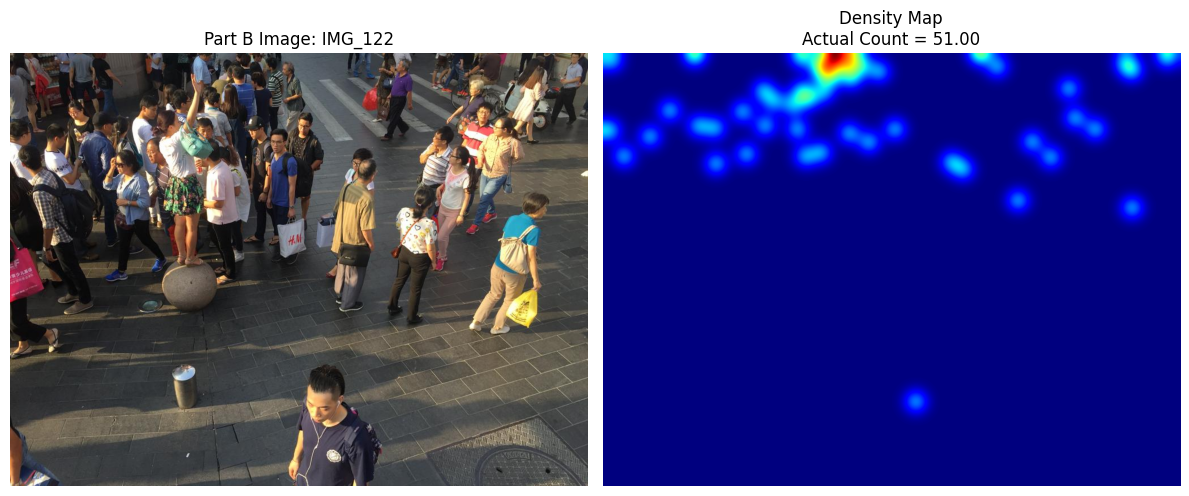

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image)
axes[0].set_title(f"Part B Image: {SAMPLE_ID}")
axes[0].axis("off")

axes[1].imshow(density, cmap="jet")
axes[1].set_title(f"Density Map\nActual Count = {actual_count:.2f}")
axes[1].axis("off")
plt.tight_layout()


## Step 2: Preprocessing

Part B also uses the same fused preprocessing idea:

- RGB image  
- CLAHE-enhanced grayscale image  
- both are combined into one fused 6-channel input

This means Part A and Part B share the same input philosophy, but differ later in model complexity.


In [14]:
rgb = image.astype(np.float32) / 255.0
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
clahe_3 = np.repeat(clahe[..., None], 3, axis=2).astype(np.float32) / 255.0
fused = np.concatenate([rgb, clahe_3], axis=2)

print("Fused input shape:", fused.shape)


Fused input shape: (768, 1024, 6)


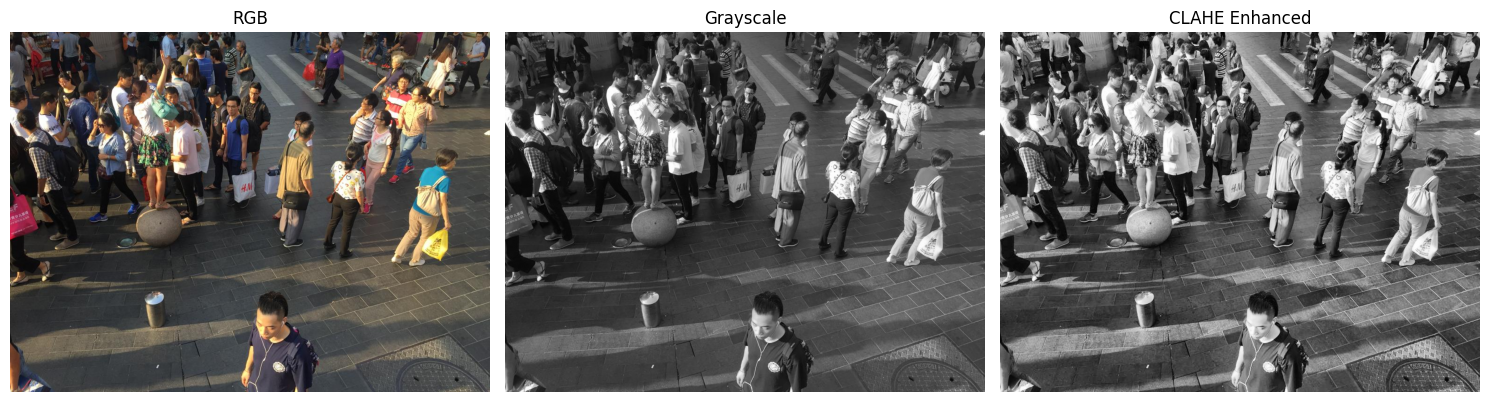

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(rgb)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(clahe, cmap="gray")
axes[2].set_title("CLAHE Enhanced")
axes[2].axis("off")
plt.tight_layout()


## Step 3: Why Part B uses a single fused model

Part B is comparatively less dense and more stable than Part A.

So instead of training three specialized models, one single model was enough.

That is why we call it **single_fused**:

- `single` = only one model is used  
- `fused` = input is RGB + CLAHE-enhanced grayscale


In [16]:
PART_B_BOUNDS = (90.0, 220.0)

def part_b_bucket(count, bounds=PART_B_BOUNDS):
    if count < bounds[0]:
        return "low-count bucket"
    if count < bounds[1]:
        return "mid-count bucket"
    return "high-count bucket"

print("Sample bucket:", part_b_bucket(actual_count))


Sample bucket: low-count bucket


## Step 4: Part B model architecture

The Part B model is simpler than Part A.

It still uses:

- residual blocks  
- squeeze-excitation attention  
- count regression  
- bucket classification

But it does **not** use the full three-model dense fusion system of Part A.


In [17]:
class SE(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(8, channels // reduction)
        self.block = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(True),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.block(x)


class RB(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.proj = (
            nn.Identity()
            if in_ch == out_ch and stride == 1
            else nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, 0),
                nn.BatchNorm2d(out_ch),
            )
        )
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride, 1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1),
            nn.BatchNorm2d(out_ch),
            SE(out_ch),
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        return self.relu(self.proj(x) + self.block(x))


class PartBNet(nn.Module):
    def __init__(self, input_channels=6):
        super().__init__()
        self.encoder = nn.Sequential(
            RB(input_channels, 32, 2),
            RB(32, 64, 2),
            RB(64, 96, 1),
            RB(96, 128, 2),
            RB(128, 160, 1),
            RB(160, 224, 2),
        )
        self.pool = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.main_head = nn.Sequential(
            nn.Linear(224, 128),
            nn.ReLU(True),
            nn.Dropout(0.2),
            nn.Linear(128, 1),
        )
        self.residual_head = nn.Sequential(
            nn.Linear(224, 96),
            nn.ReLU(True),
            nn.Dropout(0.1),
            nn.Linear(96, 1),
        )
        self.bucket_head = nn.Sequential(
            nn.Linear(224, 64),
            nn.ReLU(True),
            nn.Dropout(0.1),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        features = self.encoder(x)
        pooled = self.pool(features)
        main = self.main_head(pooled)
        residual = self.residual_head(pooled)
        bucket = self.bucket_head(pooled)
        final_count_repr = main + 0.15 * residual
        return final_count_repr, bucket


model = PartBNet(input_channels=6)
model


PartBNet(
  (encoder): Sequential(
    (0): RB(
      (proj): Sequential(
        (0): Conv2d(6, 32, kernel_size=(1, 1), stride=(2, 2))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (block): Sequential(
        (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): SE(
          (block): Sequential(
            (0): AdaptiveAvgPool2d(output_size=1)
            (1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (2): ReLU(inplace=True)
            (3): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (4): Sigmoid()
          )
        )
      )
      (relu): ReLU(inplace=True)
    )

In [18]:
param_count = sum(p.numel() for p in model.parameters())
print("Total parameters:", f"{param_count:,}")


Total parameters: 1,827,617


## Step 5: How Part B final prediction works

Part B does not use sparse/low/dense fusion.

Instead:

1. one fused model predicts the count  
2. light test-time augmentation may be used  
3. validation decides whether to keep:
   - the raw prediction
   - or a small affine-calibrated version

So the final Part B pipeline is much simpler and more stable.


In [19]:
part_b_csv = ROOT / "DATASET" / "prediction_results_part_b.csv"
if part_b_csv.exists():
    row = pd.read_csv(part_b_csv)
    row = row[row["image_id"] == SAMPLE_ID]
    display(row)
else:
    print("prediction_results_part_b.csv not found yet.")


,part,split,image_id,image_path,actual_count,strategy_name,blend_alpha,raw_predicted_count,predicted_count,signed_error,absolute_error
26,B,test,IMG_122,DATASET/part_B/test_data/images/IMG_122.jpg,50.999992,single_fused,NaN,52.547229,52.547229,1.547237,1.547237


## Final explanation for presentation

For Part B, the project uses the same fused preprocessing, but only one model is trained.

This is why it is called a **single fused model**:

- one model only  
- fused input representation  
- simpler prediction pipeline  
- no multi-model dense fusion like Part A
